In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import torchvision.transforms as transforms

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.2)

In [2]:
plt.show()

In [11]:
%matplotlib inline

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

X_train = trainset.data
y_train = np.array(trainset.targets)
class_names = trainset.classes

X_train.shape, y_train.shape

((50000, 32, 32, 3), (50000,))

In [4]:
labels_df = pd.DataFrame({
    "label": y_train.flatten()
})
labels_df["label_name"] = labels_df["label"].apply(lambda x: class_names[x])
labels_df.head()

,label,label_name
0,6,frog
1,9,truck
2,9,truck
3,4,deer
4,1,automobile


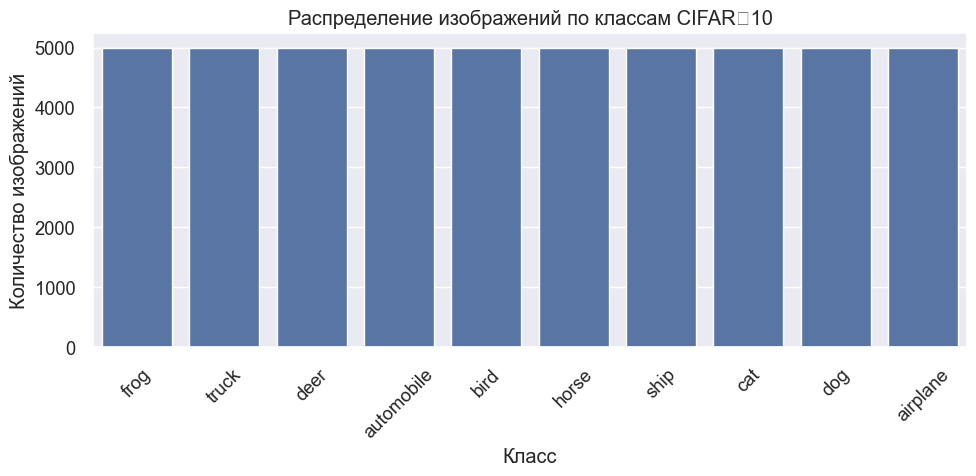

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=labels_df, x="label_name")
plt.title("Распределение изображений по классам CIFAR‑10")
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

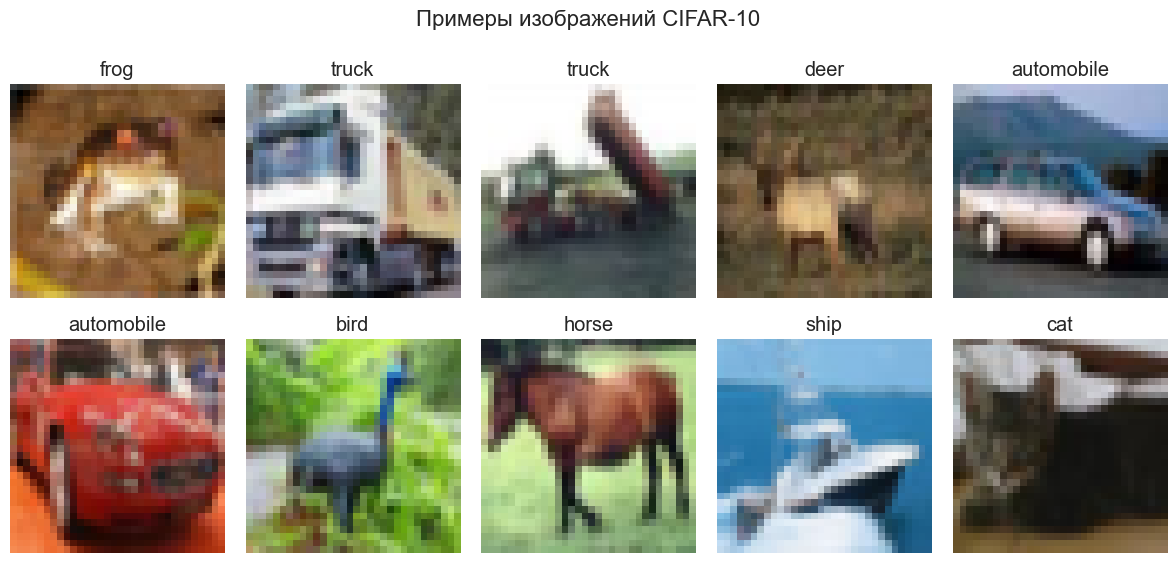

In [6]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Примеры изображений CIFAR-10", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
print("Размер обучающей выборки:", X_train.shape)
print("Размер одного изображения:", X_train[0].shape)

Размер обучающей выборки: (50000, 32, 32, 3)
Размер одного изображения: (32, 32, 3)


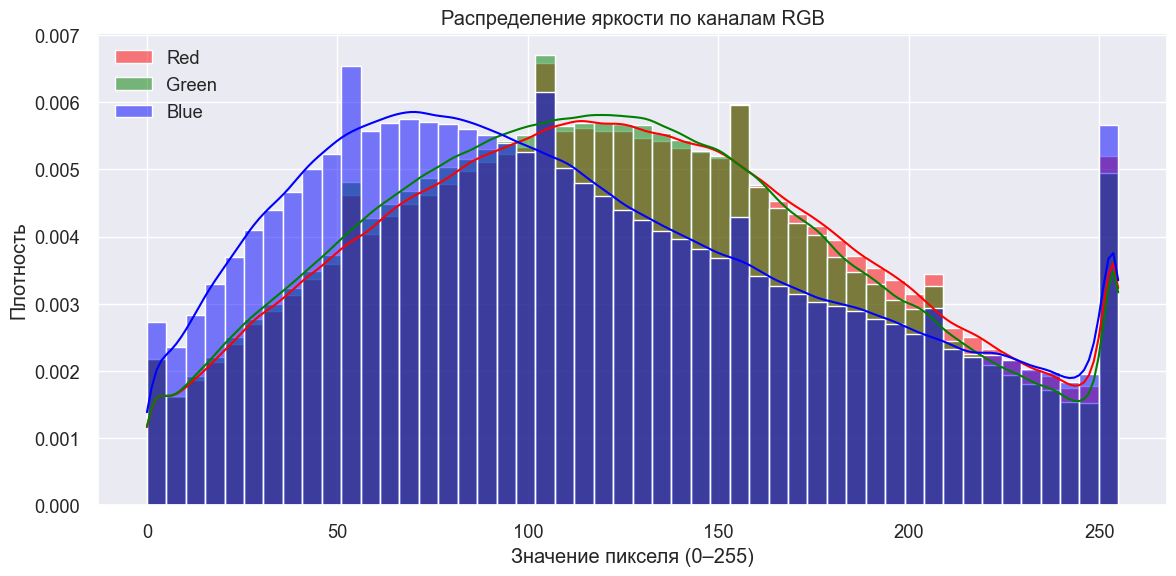

In [8]:
N = 10000
subset = X_train[:N]

r = subset[:, :, :, 0].flatten()
g = subset[:, :, :, 1].flatten()
b = subset[:, :, :, 2].flatten()

plt.figure(figsize=(12, 6))
sns.histplot(r, color="red", label="Red", kde=True, stat="density", bins=50)
sns.histplot(g, color="green", label="Green", kde=True, stat="density", bins=50)
sns.histplot(b, color="blue", label="Blue", kde=True, stat="density", bins=50)
plt.legend()
plt.title("Распределение яркости по каналам RGB")
plt.xlabel("Значение пикселя (0–255)")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()

In [9]:
print("Среднее значение пикселей:", subset.mean())
print("Стандартное отклонение:", subset.std())

Среднее значение пикселей: 121.04103444010417
Стандартное отклонение: 64.39060047846121


In [10]:
labels_df["label_name"].value_counts()

label_name
frog          5000
truck         5000
deer          5000
automobile    5000
bird          5000
horse         5000
ship          5000
cat           5000
dog           5000
airplane      5000
Name: count, dtype: int64